In [5]:
from data_utils import *


DATA_ROOT = "../outputs/combined/"
FIGURE_ROOT = Path("../outputs/plots/features")
N_RUNS = 100
N_EXAMPLES = 50

model_df = get_model_df(DATA_ROOT)
model_df = model_df[model_df["dataset_key"] != "cinic10nocifarsubset"]
model_df

,model_key,dataset_key,Model,Dataset,Task,Parameters,path,key,n_replicates
0,cifar_resnet_20_64,cifar10,ResNet wide,CIFAR-10,CIFAR-10/ResNet wide,4327754,../outputs/combined/lottery_018683f0568061c3a8...,lottery_018683f0568061c3a8b71ab3591569b8,100
1,cifar_vgg_16,cifar100,VGG-16,CIFAR-100,CIFAR-100/VGG-16,14728266,../outputs/combined/lottery_06562e05cda1bf840e...,lottery_06562e05cda1bf840ee146490815ed82,100
2,cifar_resnet_32,cifar10,ResNet deep,CIFAR-10,CIFAR-10/ResNet deep,466906,../outputs/combined/lottery_323890dc4552d843f9...,lottery_323890dc4552d843f9a1fcfe3da775bf,100
4,cifar_resnet_20,cifar10,ResNet-20 (LR=0.01),CIFAR-10,CIFAR-10/ResNet-20 (LR=0.01),272474,../outputs/combined/lottery_775f113b9c14d804ba...,lottery_775f113b9c14d804ba7b473e4ebc835f,100
5,cifar_resnet_20,cifar10,ResNet-20,CIFAR-10,CIFAR-10/ResNet-20,272474,../outputs/combined/lottery_8ae667adac9b690a88...,lottery_8ae667adac9b690a88b522e85f1388c8,100
6,cifar_resnet_20,cifar100,ResNet-20,CIFAR-100,CIFAR-100/ResNet-20,272474,../outputs/combined/lottery_9dc2b8dfff54c4da57...,lottery_9dc2b8dfff54c4da57570d7b391dcccd,100
7,cifar_resnet_20_64,cifar100,ResNet wide,CIFAR-100,CIFAR-100/ResNet wide,4327754,../outputs/combined/lottery_a8299123c240af67e9...,lottery_a8299123c240af67e983ad684c69ecb9,100
8,cifar_vgg_16,cifar10,VGG-16,CIFAR-10,CIFAR-10/VGG-16,14728266,../outputs/combined/lottery_cf40a5a8bbe4f285b8...,lottery_cf40a5a8bbe4f285b8fe317c1aa95dd5,100
9,cifar_resnet_20,cifar10,ResNet-20 (Adam),CIFAR-10,CIFAR-10/ResNet-20 (Adam),272474,../outputs/combined/lottery_efe7d47fb664dce783...,lottery_efe7d47fb664dce78349cfa2ff31da4c,100


In [6]:
CV_MODELS = [
    "ResNet-20",
    "ResNet-20 (Adam)",
    "ResNet-20 (LR=0.01)",
    "ResNet wide",
    "ResNet deep",
    "VGG-16",
]

SELECTED_SCORES = [
    {"key": "loss",
    "Method": "Training",
    "Type": ""},
    {"key": "margin",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "carlini_conf"},
    {"key": "batch_countforget",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "el2n",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "classvog",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "selfproto",
    "Method": "One Step",
    "Type": "",
    "Epoch": 160},
    {"key": "pd",
    "Method": "One Step",
    "Type": "",
    "Epoch": 160},
    {"key": "carlini_ret"},
]

ALL_SCORES = [
    {"key": "carlini_agr"},
    {"key": "ddd",
    "Method": "Ensemble",
    "Type": "",
    "Epoch": 160},
    {"key": "ddd",
    "Method": "Ensemble",
    "Type": "",
    "Epoch": 20},
    {"key": "acc",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "acc",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "loss",
    "Method": "Training",
    "Type": ""},
    {"key": "margin",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "conf",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "maxconf",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "carlini_conf"},
    {"key": "batch_countforget",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "countforget",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "batch_firstlearn",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "firstlearn",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "batch_firstunforgettable",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "firstunforgettable",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "batch_unforgettable",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "unforgettable",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "el2n",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "el2n",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "grand",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "grand",
    "Method": "One Step",
    "Type": "",
    "Epoch": 160},
    {"key": "classvog",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "lossvog",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "proto",
    "Method": "One Step",
    "Type": "",
    "Epoch": 160},
    {"key": "proto",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "selfproto",
    "Method": "One Step",
    "Type": "",
    "Epoch": 160},
    {"key": "selfproto",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "swav_selfproto"},
    {"key": "pd",
    "Method": "One Step",
    "Type": "",
    "Epoch": 160},
    {"key": "pd",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "carlini_ret"},
    {"key": "carlini_adv"},
    {"key": "carlini_priv"},
    {"key": "memorization"},
    {"key": "memorization_inception"},
]

In [7]:
import warnings
from itertools import product, combinations
from scipy.stats import ttest_ind
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.decomposition import PCA, FactorAnalysis
from scipy.optimize import linear_sum_assignment
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import MaxAbsScaler
from sklearn.linear_model import LogisticRegression


def plot_lda(X, y_true, y_pred=None, name=None, ax=None, title=None, x_label=None):
    n_components = min(2, X.shape[1], len(set(y_true)) - 1)
    lda = LinearDiscriminantAnalysis(n_components=n_components)
    # add a bit of noise as sometimes lda doesn't work otherwise, this only affects the visual placement of the points so it's okay
    lda = lda.fit(X + np.random.randn(*X.shape) * 1e-6, y_true)
    X_r2 = lda.transform(X)
    x_values = X_r2[:, 0]  if n_components > 1 else X[:, 0]
    y_values = X_r2[:, 1] if n_components > 1 else np.random.uniform(-0.5, 0.5, size=X_r2[:, 0].shape)

    ax = sns.scatterplot(x=x_values, y=y_values, hue=y_true, style=y_pred, ax=ax)
    ax.set_xlabel("LDA 1" if x_label is None else x_label)
    ax.set_ylabel("LDA 2" if n_components > 1 else "")
    if title is not None:
        ax.set_title(title)
    if n_components > 1:
        ax.set(xticklabels=[])
    else:
        ax.set_ylim(-1, 1)  # make it look like a strip plot
    ax.set(yticklabels=[])

    if title is not None:
        save_fig(FIGURE_ROOT, "lda", name=name)
    return lda, ax


def get_features(df, select_attrs=None, idx=None, avg_over_examples=False, normalize=True, merge_score_dim=True):
    stds, means = [], []
    features, targets = [], []

    for model, sub_df in df.groupby("Model"):
        std, mean  = [], []
        model_features = []

        rows = [(x, x["array"]) for _, x in sub_df.iterrows()] if select_attrs is None else get_selected_scores(sub_df, select_attrs, strict=False)
        for row, score in rows:
            # get mean, std over all examples and runs, whether they are selected or not
            std.append(np.std(score))
            mean.append(np.mean(score))

            if idx is not None:
                score = score[:, idx]
            if avg_over_examples:
                score = np.mean(score, axis=1, keepdims=True)
            model_features.append(score)  # (runs, examples)

        stds.append(np.stack(std))
        means.append(np.stack(mean))
        features.append(np.stack(model_features, axis=-1))  # (runs, examples, scores)
        targets += [model] * len(score)  # (runs,)

    features = np.concatenate(features, axis=0)  # (models * runs, examples, scores)

    if normalize:  # standardize over each score to make them comparable
        # average over all models to get one scaling factor per score
        means = np.mean(np.stack(means), axis=0)
        stds = np.mean(np.stack(stds, axis=0), axis=0)  # (scores,)
        features = (features - means) / stds

    if merge_score_dim:
        features = features.reshape(features.shape[0], -1)

    return features, targets


def rename_labels(labels, mapping_dict):
    return [mapping_dict[x] for x in labels]


def one_hot_encoding(labels, size=None):
    ids = [None for _ in range(size)]
    for i, l in enumerate(np.unique(labels)):
        ids[i] = l
    if size is None:
        size = len(ids)
    labels_to_ids = {j: i for i, j in enumerate(ids)}
    y = rename_labels(labels, labels_to_ids)
    output = np.zeros([len(labels), size])
    output[np.arange(len(labels)), y] = 1
    return output, ids


def match_labels(pred_y, true_y, n_labels):
    A, pred_labels = one_hot_encoding(pred_y, n_labels)
    B, true_labels = one_hot_encoding(true_y, n_labels)
    cost = A.T @ B
    r, c = linear_sum_assignment(cost, maximize=True)
    true_to_pred = {true_labels[i]: pred_labels[j] for i, j in zip(r, c)}
    pred_to_true = {pred_labels[i]: true_labels[j] for i, j in zip(r, c)}
    return pred_to_true, true_to_pred


def fit_kmeans(X, y):
    cluster = KMeans(len(set(y)))
    cluster.fit(X)
    return cluster


def fit_lda(X, y):
    n_components = min(X.shape[1], len(set(y)) - 1)
    lda = LinearDiscriminantAnalysis(n_components=n_components)
    lda.fit(X, y)
    return lda


def fit_logistic(X, y, C=1, penalty="l2"):
    solver = "lbfgs" if penalty == "l2" else "saga"
    classifier = LogisticRegression(penalty=penalty, solver=solver, C=C, max_iter=5e3)
    classifier.fit(X, y)
    return classifier


def fit_logistic_tuned(X, y, plot=False, cv_folds=4, Cs=None, penalty="l2"):
    if Cs is None:
        Cs = [10**c for c in np.linspace(-2, 3, 6)]
    accs = []
    for i in range(cv_folds):
        train_idx = np.ones(len(y), dtype=bool)
        train_idx[np.arange(i, len(y), cv_folds)] = False
        val_idx = np.logical_not(train_idx)
        X_tr, y_tr = X[train_idx], np.array(y)[train_idx]
        X_val, y_val = X[val_idx], np.array(y)[val_idx]
        acc = []
        for c in Cs:
            logreg = fit_logistic(X_tr, y_tr, C=c, penalty=penalty)
            _, a = predict(logreg, X_val, y_val)
            acc.append(a)
        accs.append(np.array(acc))
    accs = np.mean(np.stack(accs), axis=0)
    if plot:
        ax = sns.lineplot(x=Cs, y=accs)
        ax.set_xscale("log")
        ax.set_ylim(0, 1)
        plt.show()
    i = np.argmax(accs)
    return fit_logistic(X, y, C=Cs[i], penalty=penalty)


def predict(obj, X, y):
    y_pred = obj.predict(X)
    if isinstance(obj, KMeans):
        pred_to_true, _ = match_labels(y_pred, y, obj.n_clusters)
        y_pred = rename_labels(y_pred, pred_to_true)
    accuracy = np.mean([a == b for a, b in zip(y_pred, y)])
    return y_pred, accuracy


def plot_cluster_acc_vs_n_examples(cluster_df, name=None):
    ax = sns.lineplot(data=cluster_df, x="Number of Examples", y="Classification Accuracy", 
    hue="Example Selection", style="Distribution")
    ax.set_ylim(0, 1)
    ax.set_xscale("log")
    save_fig(FIGURE_ROOT, "cluster", name=name)


def split_replicates(df, replicate_idx, n_replicates):
    replicate_idx = np.sort(replicate_idx)
    test_idx = np.delete(np.arange(n_replicates), replicate_idx)
    id_array = df["array"].apply(lambda x: x[replicate_idx] if len(x) == n_replicates else x)
    ood_array = df["array"].apply(lambda x: x[test_idx] if len(x) == n_replicates else x)
    id_df = df.assign(array=id_array, Replicate=[replicate_idx] * len(df))
    ood_df = df.assign(array=ood_array, Replicate=[test_idx] * len(df))
    return id_df, ood_df


# create held out sets of id/ood models and also split replicates between train and test
def cv_splits(df, leave_one_out_models=None, n_replicates=100, train_frac=0.5, n_splits=2):
    if leave_one_out_models is None:
        leave_one_out_models = list(df["Model"].unique())
    for od_model, i in product(leave_one_out_models, range(n_splits)):
        split_point = int(n_replicates * train_frac)
        idx = np.random.permutation(n_replicates)
        train_idx = np.sort(idx[:split_point])
        test_idx = np.sort(idx[split_point:])

        id_df = df[df["Model"] != od_model]
        od_df = df[df["Model"] == od_model]
        train_id, test_id = split_replicates(id_df, train_idx, n_replicates)
        train_od, test_od = split_replicates(od_df, test_idx, n_replicates)
        yield train_id, test_id, train_od, test_od, (od_model, i, train_idx, test_idx)


# score examples by pvalue or PCA
def example_pvalues(df):
    models = list(df["Model"].unique())
    new_df = []
    # for every model pair, run a t-test between scores
    for k, sub_df in df.groupby(GROUPBY_COLS):
        for model_a, model_b in combinations(models, 2):
            (_, score_a), (_, score_b) = get_selected_scores(sub_df, [{"Model": model_a}, {"Model": model_b}])
            pvalue = ttest_ind(score_a, score_b, equal_var=False).pvalue
            # test can return nan if both score_a and score_b are uniformly the same, replace with pvalue=1.0
            pvalue[np.isnan(pvalue)] = 1.0
            new_df.append({
                "Score": sub_df.iloc[0]["Short Name"],
                "Model Pair": (model_a, model_b),
                "P-Value": pvalue,
            })
    new_df = pd.DataFrame(new_df)
    # aggregate t-test p-values using geometric mean
    return new_df


def aggregate_over_examples_and_scores(coefficients, E, S, agg_method):
    abs_coef = np.abs(coefficients)  # (models, examples*scores)
    M = abs_coef.shape[0]
    abs_coef = abs_coef.reshape(M, E, S)  # (models, examples, scores)
    abs_coef = np.moveaxis(abs_coef, 2, 1).reshape(M * S, E)  # (models * scores, examples)
    # aggregate over models and scores
    coef = agg_method(abs_coef, axis=0)
    return coef


def pvalue_select_examples(df, agg_method=np.min, epsilon=1e-15):
    pval = np.stack(example_pvalues(df)["P-Value"])
    log_pval = -1 * np.log(pval + epsilon)
    log_pval = agg_method(log_pval, axis=0)
    return log_pval


def logreg_select_examples(df, agg_method=np.mean, penalty="l2"):
    X, y_true = get_features(df, idx=None, merge_score_dim=False)
    R, E, S = X.shape  # (models * runs, examples, scores)
    X = X.reshape(R, E*S)   # (models * runs, examples * scores)
    logreg = fit_logistic_tuned(X, y_true, penalty=penalty)
    coef = aggregate_over_examples_and_scores(logreg.coef_, E, S, agg_method)
    return coef


def hardest_select_examples(df, agg_method=np.median):
    X, y_true = get_features(df, idx=None, merge_score_dim=False)
    R, E, S = X.shape  # (models * runs, examples, scores)
    ranks = rankdata(X, axis=1)
    ranks = ranks.reshape(R, E*S)   # (models * runs, examples * scores)
    ranks = aggregate_over_examples_and_scores(ranks, E, S, agg_method)
    return ranks


def pca_select_examples(df, agg_method=np.mean, use_factor=False, components=None):
    X, y_true = get_features(df, idx=None, merge_score_dim=False)
    components = len(set(y_true)) if components is None else components
    R, E, S = X.shape  # (models * runs, examples, scores)
    X = X.reshape(R, E*S)   # (models * runs, examples * scores)
    if use_factor:
        means = np.zeros_like(X)
        for label in set(y_true):
            i = label == np.array(y_true)
            means[i] = np.mean(X[i], axis=0)
        var_init = np.mean((X - means)**2, axis=0)
        pca = FactorAnalysis(components, noise_variance_init=var_init)
    else:
        pca = PCA(components)
    pca.fit(X)
    coef = aggregate_over_examples_and_scores(pca.components_, E, S, agg_method)
    return coef


def top_median_bottom_idx(scores, k):
    idx = np.argsort(scores)
    bottom = idx[:k]
    # put ones closest to median first
    median = idx[np.argsort(np.abs(np.arange(len(scores)) - len(scores) / 2))[:k]]
    # flip so the topmost comes first
    top = np.flip(idx[-k:])
    return top, median, bottom

In [8]:
FIT_FUNCTIONS = [
    ("K-Means", fit_kmeans),
    ("Logistic", fit_logistic_tuned),
]

N_ITERS = 5

LOSS_SCORES = [
    {"key": "loss",
    "Method": "One Step",
    "Type": ""},
]

In [9]:
dfs = []
for _, model_row in model_df.iterrows():
    print(model_row)
    task_name = model_row["Task"]

    score_df = get_score_df(model_row, n_replicates=N_RUNS)
    score_df = score_df[score_df["Epoch"] != 0]
    loss_df = multi_filter_df(score_df, LOSS_SCORES)
    score_df = multi_filter_df(score_df, SELECTED_SCORES)
    df = get_scores(score_df, n_examples=N_EXAMPLES, fuzz_by=0, invert=True)
    training_loss = aggregate_steps(get_scores(loss_df, n_examples=N_EXAMPLES, fuzz_by=0, invert=False))
    training_loss["Epoch"] = training_loss["Epoch"].apply(lambda x: max(x))
    df = pd.concat([df, training_loss])
    df = df[(df["Method"] != "Ensemble")]
    df["Model"] = model_row["Model"]
    df["Dataset"] = model_row["Dataset"]
    dfs.append(df)
dfs = pd.concat(dfs)

cifar10_df = dfs[dfs["Dataset"] == "CIFAR-10"]
dfs


model_key                                      cifar_resnet_20_64
dataset_key                                               cifar10
Model                                                 ResNet wide
Dataset                                                  CIFAR-10
Task                                         CIFAR-10/ResNet wide
Parameters                                                4327754
path            ../outputs/combined/lottery_018683f0568061c3a8...
key                      lottery_018683f0568061c3a8b71ab3591569b8
n_replicates                                                  100
Name: 0, dtype: object
model_key                                            cifar_vgg_16
dataset_key                                              cifar100
Model                                                      VGG-16
Dataset                                                 CIFAR-100
Task                                             CIFAR-100/VGG-16
Parameters                                           

,Path,Replicate,Epoch,Method,Short Name,Full Name,Type,key,is_fuzzed,is_inverted,array,Model,Dataset
0,../outputs/combined/lottery_018683f0568061c3a8...,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",160,Training,Forgetting,Forgetting,,batch_countforget,False,False,"[[5.0, 0.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0,...",ResNet wide,CIFAR-10
1,../outputs/combined/lottery_018683f0568061c3a8...,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",160,Training,VoG,VoG,,classvog,False,False,"[[0.00012768529235164175, 1.4152428382892776e-...",ResNet wide,CIFAR-10
2,../outputs/combined/lottery_018683f0568061c3a8...,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",20,One Step,EL2N,EL2N (20ep),,el2n,False,False,"[[0.0015033168993041667, 7.552238875753661e-06...",ResNet wide,CIFAR-10
3,../outputs/combined/lottery_018683f0568061c3a8...,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",160,Training,Area Under Margin,Area Under Margin,,margin,False,True,"[[-0.9459145794920557, -0.9996723953172145, -0...",ResNet wide,CIFAR-10
4,../outputs/combined/lottery_018683f0568061c3a8...,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",160,One Step,Prediction Depth,Prediction Depth (160ep),,pd,False,False,"[[7, 7, 8, 1, 4, 7, 7, 4, 7, 8, 3, 7, 8, 7, 7,...",ResNet wide,CIFAR-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,../outputs/combined/lottery_efe7d47fb664dce783...,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",20,One Step,EL2N,EL2N (20ep),,el2n,False,False,"[[0.010289327296884272, 8.824582793563705e-07,...",ResNet-20 (Adam),CIFAR-10
3,../outputs/combined/lottery_efe7d47fb664dce783...,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",160,Training,Area Under Margin,Area Under Margin,,margin,False,True,"[[-0.8779799243163615, -0.9666146269355793, -0...",ResNet-20 (Adam),CIFAR-10
4,../outputs/combined/lottery_efe7d47fb664dce783...,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",160,One Step,Prediction Depth,Prediction Depth (160ep),,pd,False,False,"[[4, 6, 8, 0, 4, 4, 8, 4, 3, 6, 4, 6, 8, 6, 6,...",ResNet-20 (Adam),CIFAR-10
5,../outputs/combined/lottery_efe7d47fb664dce783...,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",160,One Step,Self-Supervised Prototypes,Self-Supervised Prototypes (160ep),,selfproto,False,False,"[[2.766862588562788, 2.17732633050522, 3.39148...",ResNet-20 (Adam),CIFAR-10


In [10]:
import traceback

# #DEBUGGING
# EXAMPLE_SUBSETS = [1, 10]
# N_SPLITS = 2
# FEATURE_SELECTORS = [
#     ("Random", lambda df: np.random.permutation(N_EXAMPLES)),
#     ("P-Value", lambda df: pvalue_select_examples(df, agg_method=np.mean)),
#     ("Difficulty", lambda df: hardest_select_examples(df)),
# ]

EXAMPLE_SUBSETS = [1, 10, 100, 1000]

N_SPLITS = 20

FEATURE_SELECTORS = [
    ("Random", lambda df: np.random.permutation(N_EXAMPLES)),
    ("P-Value", lambda df: pvalue_select_examples(df, agg_method=np.mean)),
    # ("P-Value Bonferroni", lambda df: pvalue_select_examples(df, epsilon=0.01 / N_EXAMPLES)),
    # ("P-Value Min", lambda df: pvalue_select_examples(df, agg_method=np.min)),
    ("Logistic", lambda df: logreg_select_examples(df)),
    # ("Logistic Min", lambda df: logreg_select_examples(df, agg_method=np.min)),
    # ("Ridge", lambda df: logreg_select_examples(df, penalty="l1")),
    ("PCA", lambda df: pca_select_examples(df, use_factor=False)),
    # ("PCA 1", lambda df: pca_select_examples(df, use_factor=False, components=1)),
    # ("Factor Analysis", lambda df: pca_select_examples(df, use_factor=True)),
    # ("Factor Analysis 1", lambda df: pca_select_examples(df, use_factor=True, components=1)),
    ("Difficulty", lambda df: hardest_select_examples(df)),
    # ("Difficulty Min", lambda df: hardest_select_examples(df, agg_method=np.min)),
]

PER_SCORE_SELECTORS = FEATURE_SELECTORS[:2]  # only do a subset of feature selectors when looking at individual scoring methods, to save computation

CLASSIFIERS = [
    ("K-Means", fit_kmeans),
    ("Logistic", fit_logistic_tuned),
]


def cluster_acc_vs_n_examples(train_id, train_od, test_id, test_od, feature_selectors, n_examples, classifiers, order_subset={"Top", "Bottom"}):
    train_df = pd.concat([train_id, train_od])
    select_df = []
    result_df = []

    for select_name, select_fn in feature_selectors:
        print(select_name)

        select_score = None
        try:
            select_score = select_fn(train_id)
        except Exception as e:
            print(traceback.format_exc())
            return train_d, select_score
        select_df.append({
            "Feature Selection": select_name,
            "Selection Score": select_score,
        })
        top, median, bottom = top_median_bottom_idx(select_score, max(n_examples))

        for n, (order, idx) in product(n_examples, [("Top", top), ("Median", median), ("Bottom", bottom)]):
            if order not in order_subset:
                continue

            X_tr, y_tr = get_features(train_df, idx=idx[:n], avg_over_examples=False)
            X_id, y_id = get_features(test_id, idx=idx[:n], avg_over_examples=False)
            X_od, y_od = get_features(test_od, idx=idx[:n], avg_over_examples=False)

            for classifier_name, fit_fn in classifiers:
                classifier = None
                try:
                    classifier = fit_fn(X_tr, y_tr)

                    for split, X, y in [("In Distribution", X_id, y_id), ("Held Out", X_od, y_od)]:
                        y_pred, acc = predict(classifier, X, y)
                        result_df.append({
                            "Feature Selection": select_name,
                            "Classifier": classifier_name,
                            "Examples": n,
                            "Accuracy": acc,
                            "Distribution": split,
                            "Predictions": y_pred,
                            "Selection Order": order,
                        })
                except Exception as e:
                    print(classifier_name, n, order, e)
                    return idx, train_df, test_id, test_od, X_tr, y_tr, X_id, y_id, X_od, y_od, classifier

    result_df = pd.DataFrame(result_df)
    select_df = pd.DataFrame(select_df)
    return result_df, select_df


def load_saved(name):
    selected_df = []
    for f in FIGURE_ROOT.rglob(name + "_summary.csv"):
        df = pd.read_csv(f, index_col=False)
        array = np.load(f.parent / (name + "_summary.npz"))
        df["Selection Score"] = [x for x in array["arr_0"]]
        selected_df.append(df)
    if len(selected_df) == 0:
        return None, None
    selected_df = pd.concat(selected_df)
    result_df = pd.concat([pd.read_csv(f, index_col=False) for f in FIGURE_ROOT.rglob(name + "_results.csv")])
    return result_df, selected_df


def save_results(results, selected, save_name):
    results.to_csv(FIGURE_ROOT / f"{save_name}_results.csv", index=False)
    selected.to_csv(FIGURE_ROOT / f"{save_name}_summary.csv", index=False)
    # save arrays separately
    np.savez(FIGURE_ROOT / f"{save_name}_summary.npz", np.stack(selected["Selection Score"]))


def feature_select_experiment(df, feature_selectors, n_examples, classifiers, save_name=None):
    if save_name is not None:
        results, selected = load_saved(save_name)
        if results is not None:
            print("Loaded from files")
            return results, selected

    results, selected = [], []
    for train_id, test_id, train_od, test_od, (od_model, i, train_idx, test_idx) in cv_splits(df, n_replicates=N_RUNS, n_splits=N_SPLITS):
        output = cluster_acc_vs_n_examples(train_id, train_od, test_id, test_od, feature_selectors, n_examples, classifiers)

        result_df, select_df = output
        result_df["Held Out Model"] = od_model
        result_df["Split"] = i
        results.append(result_df)

        select_df["Held Out Model"] = od_model
        select_df["Split"] = i
        selected.append(select_df)

    results = pd.concat(results)
    selected = pd.concat(selected)

    # selection order doesn't matter for random
    results[results["Feature Selection"] == "Random"]["Selection Order"] = "Top"

    if save_name is not None:
        save_results(results, selected, save_name)
    return results, selected


def plot_feature_select_acc(df, feature_selectors, classifiers, title, name=None):
    # sort by feature_selectors
    df = pd.concat([df[df["Feature Selection"] == x] for x in feature_selectors])

    for classifier, _ in classifiers:
        ax = sns.lineplot(data=df[df["Classifier"] == classifier], x="Examples", y="Accuracy", hue="Feature Selection", style="Distribution")
        ax.set_xscale("log")
        ax.set_ylim(0, 1)
        ax.set_title(f'{title} ({classifier})')
        save_fig(FIGURE_ROOT, f"feature_select_acc_{classifier}", name)


def plot_all_score_results(result_df, select_df, name):
    results_to_plot = result_df[result_df["Examples"].isin(EXAMPLE_SUBSETS)]

    for ord, sub_df in results_to_plot.groupby(["Selection Order"]):
        plot_feature_select_acc(sub_df, [x[0] for x in FEATURE_SELECTORS], CLASSIFIERS, ord, name=f"{name} {ord} all")
        plot_feature_select_acc(sub_df, ["Random", "P-Value", "Difficulty"], CLASSIFIERS, ord, name=f"{name} {ord}")


    all_select_method = [x for x, _ in FEATURE_SELECTORS[1:]]  # exclude random order
    # sort by method
    all_select_scores = [np.stack(select_df[select_df["Feature Selection"] == x]["Selection Score"]) for x in all_select_method]
    all_select_scores = np.stack(all_select_scores).reshape(len(all_select_scores), -1)

    matrix = corr_matrix(all_select_scores)
    plot_corr_matrix(matrix, "", "", all_select_method)
    save_fig(FIGURE_ROOT, "feature_selector_corr", name)

Loaded from files
Saving figure to ../outputs/plots/features/CIFAR-10_Bottom_all_feature_select_acc_K-Means.pdf


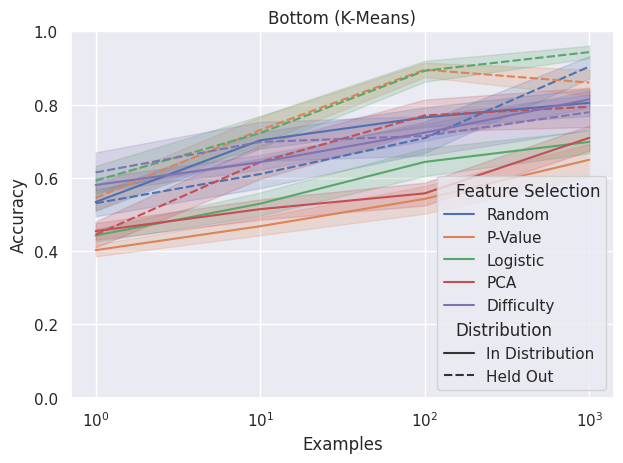

Saving figure to ../outputs/plots/features/CIFAR-10_Bottom_all_feature_select_acc_Logistic.pdf


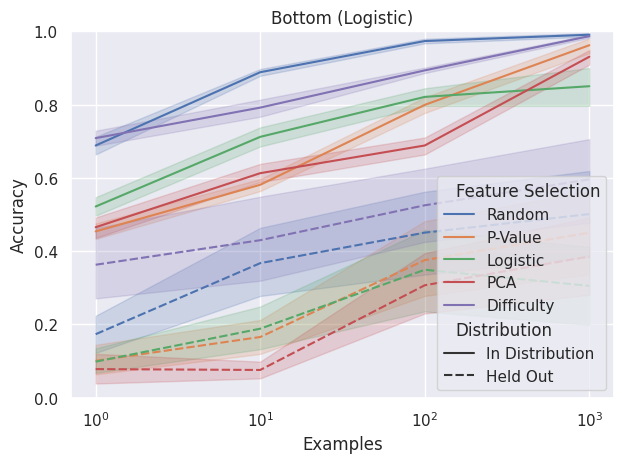

Saving figure to ../outputs/plots/features/CIFAR-10_Bottom_feature_select_acc_K-Means.pdf


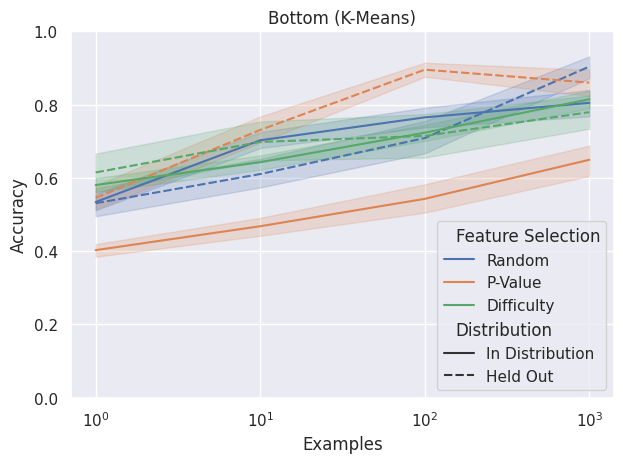

Saving figure to ../outputs/plots/features/CIFAR-10_Bottom_feature_select_acc_Logistic.pdf


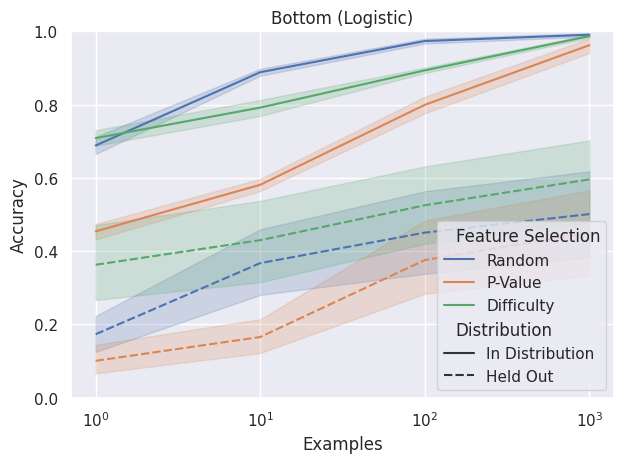

Saving figure to ../outputs/plots/features/CIFAR-10_Top_all_feature_select_acc_K-Means.pdf


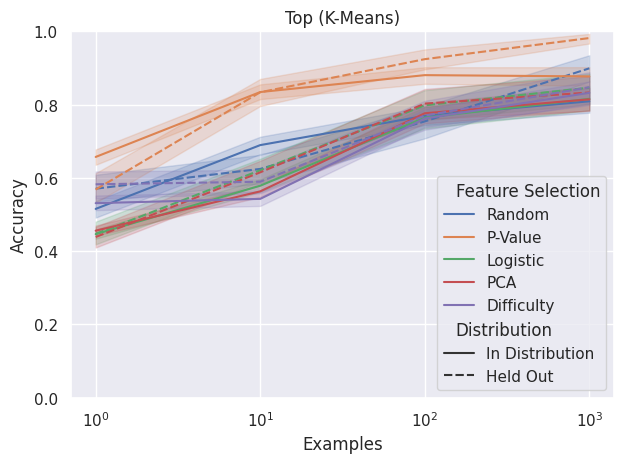

Saving figure to ../outputs/plots/features/CIFAR-10_Top_all_feature_select_acc_Logistic.pdf


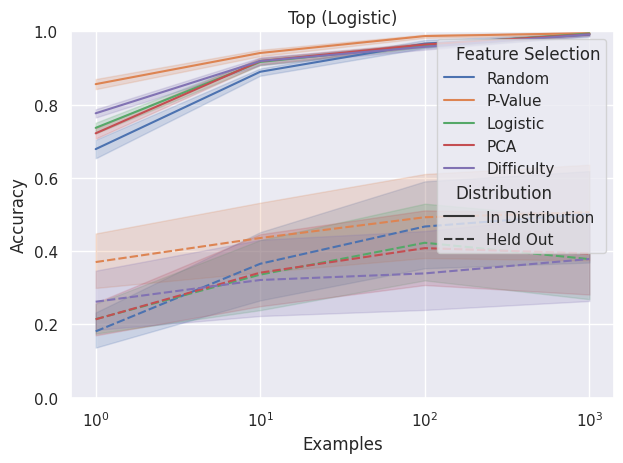

Saving figure to ../outputs/plots/features/CIFAR-10_Top_feature_select_acc_K-Means.pdf


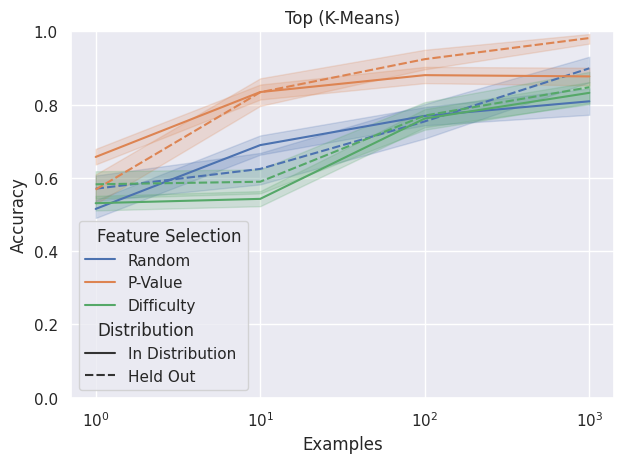

Saving figure to ../outputs/plots/features/CIFAR-10_Top_feature_select_acc_Logistic.pdf


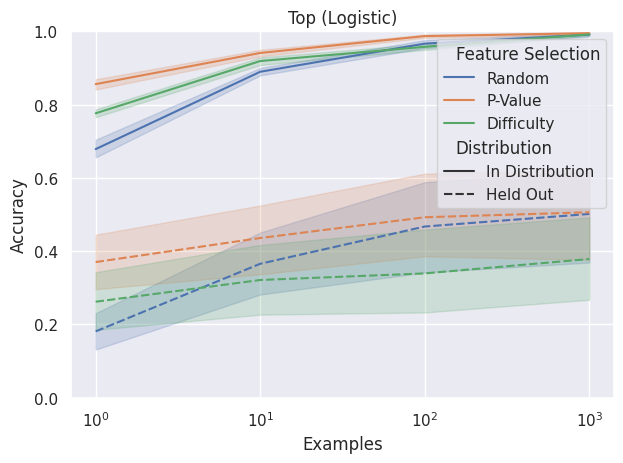

Saving figure to ../outputs/plots/features/CIFAR-10_feature_selector_corr.pdf


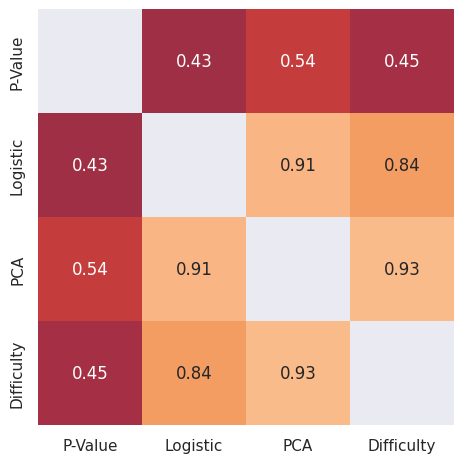

Loaded from files
Loaded from files
Loaded from files
Loaded from files
Loaded from files
Loaded from files
Loaded from files
Saving figure to ../outputs/plots/features/CIFAR-10_Area_Under_Margin_Bottom_feature_select_acc_K-Means.pdf


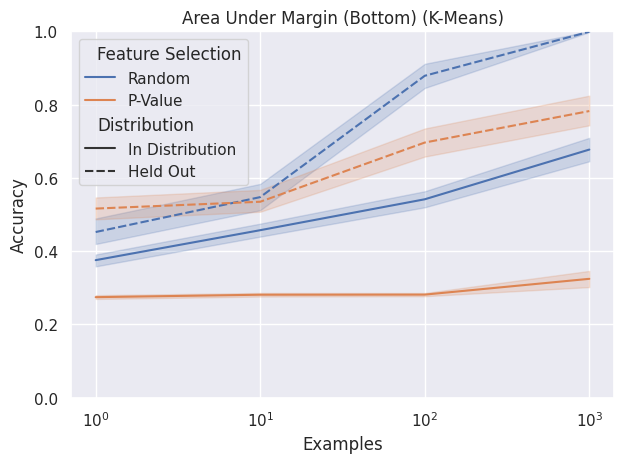

Saving figure to ../outputs/plots/features/CIFAR-10_Area_Under_Margin_Bottom_feature_select_acc_Logistic.pdf


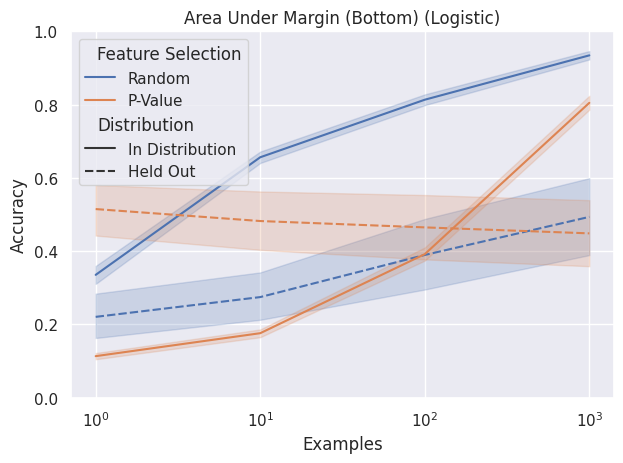

Saving figure to ../outputs/plots/features/CIFAR-10_Area_Under_Margin_Top_feature_select_acc_K-Means.pdf


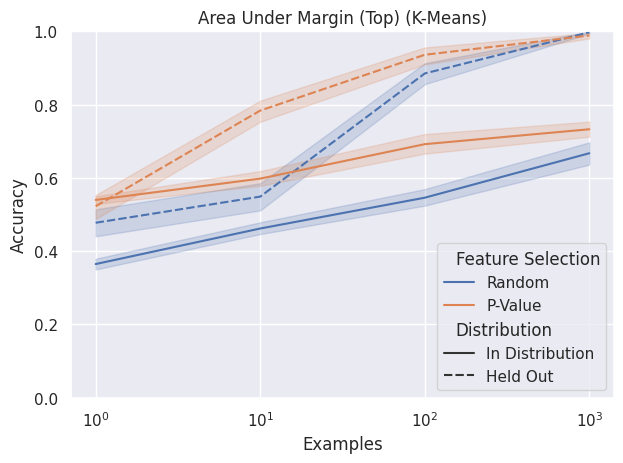

Saving figure to ../outputs/plots/features/CIFAR-10_Area_Under_Margin_Top_feature_select_acc_Logistic.pdf


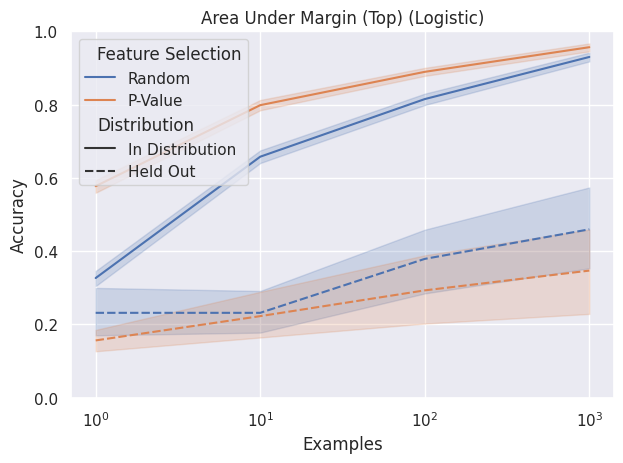

Saving figure to ../outputs/plots/features/CIFAR-10_EL2N_Bottom_feature_select_acc_K-Means.pdf


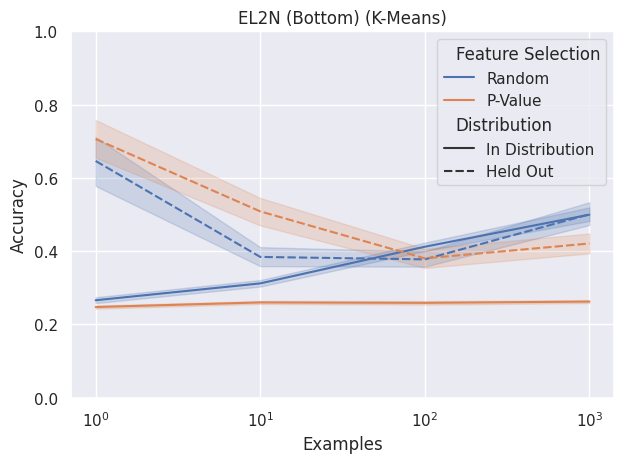

Saving figure to ../outputs/plots/features/CIFAR-10_EL2N_Bottom_feature_select_acc_Logistic.pdf


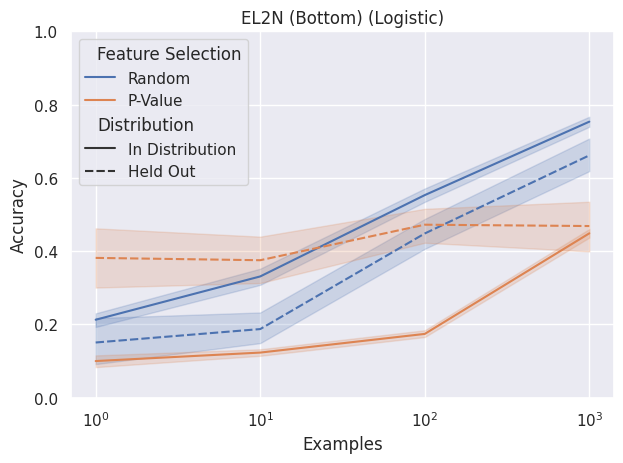

Saving figure to ../outputs/plots/features/CIFAR-10_EL2N_Top_feature_select_acc_K-Means.pdf


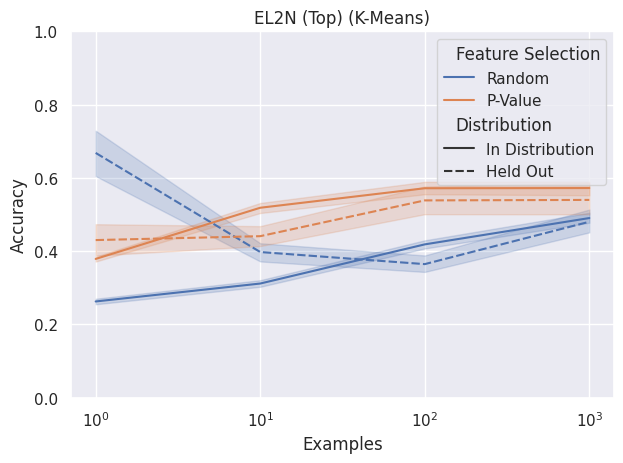

Saving figure to ../outputs/plots/features/CIFAR-10_EL2N_Top_feature_select_acc_Logistic.pdf


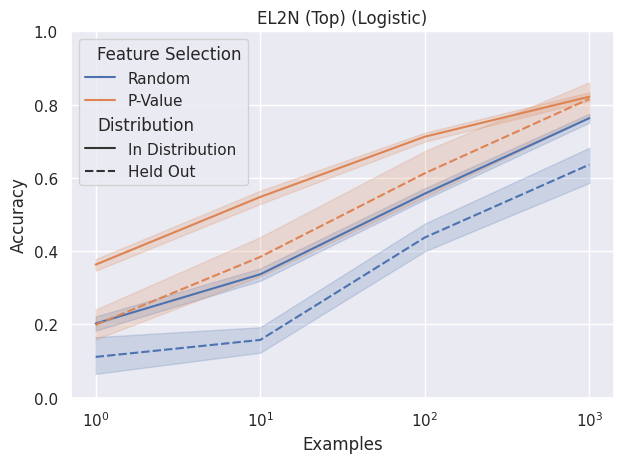

Saving figure to ../outputs/plots/features/CIFAR-10_Forgetting_Bottom_feature_select_acc_K-Means.pdf


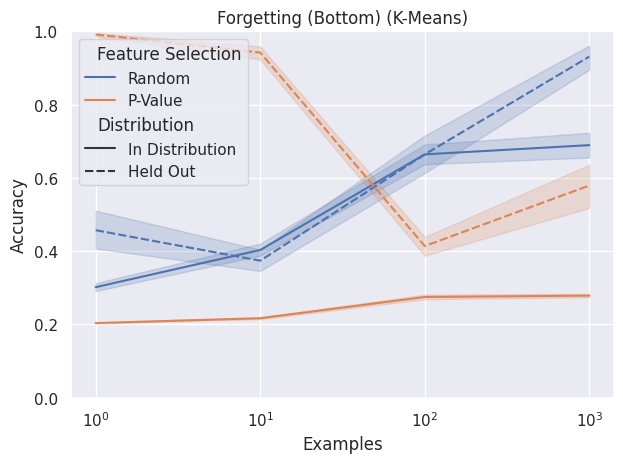

Saving figure to ../outputs/plots/features/CIFAR-10_Forgetting_Bottom_feature_select_acc_Logistic.pdf


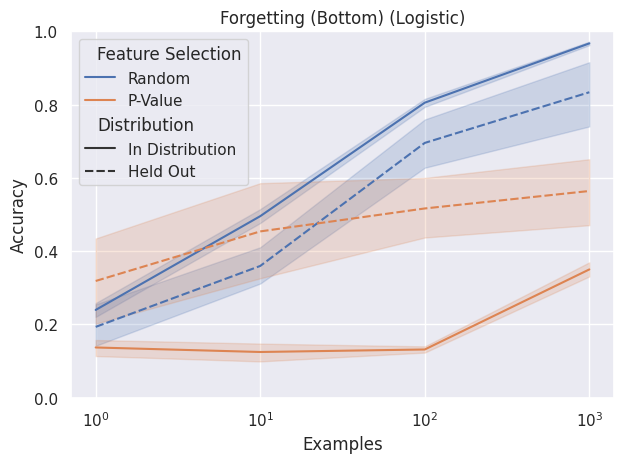

Saving figure to ../outputs/plots/features/CIFAR-10_Forgetting_Top_feature_select_acc_K-Means.pdf


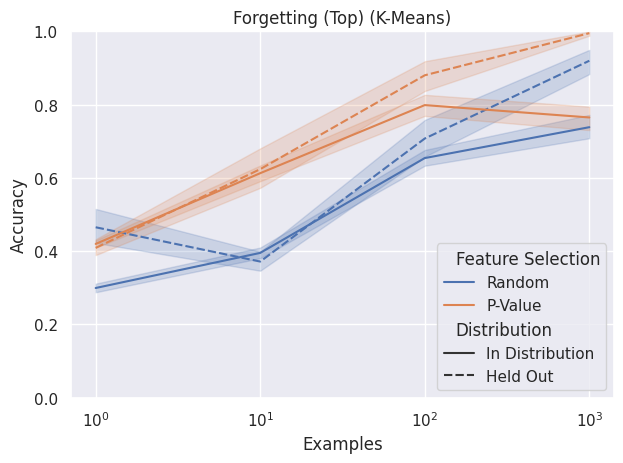

Saving figure to ../outputs/plots/features/CIFAR-10_Forgetting_Top_feature_select_acc_Logistic.pdf


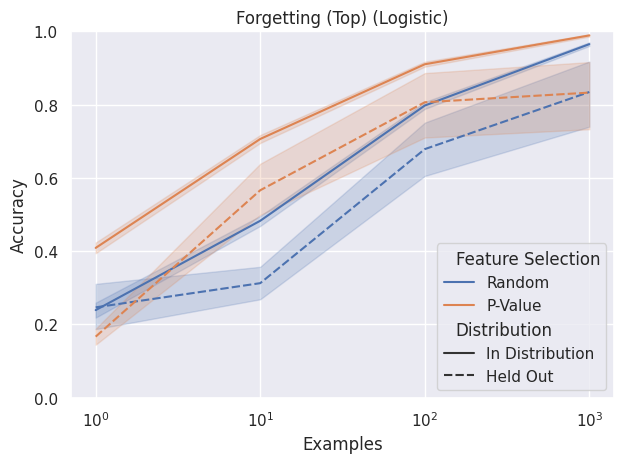

Saving figure to ../outputs/plots/features/CIFAR-10_Loss_Bottom_feature_select_acc_K-Means.pdf


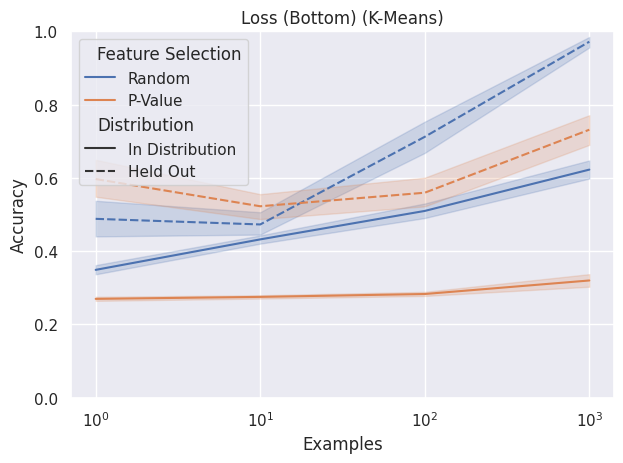

Saving figure to ../outputs/plots/features/CIFAR-10_Loss_Bottom_feature_select_acc_Logistic.pdf


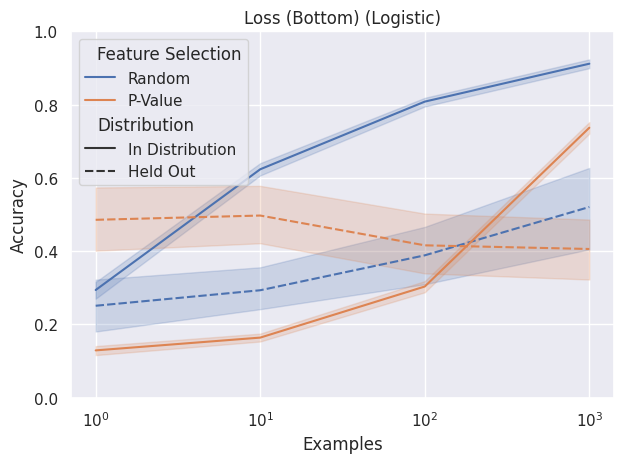

Saving figure to ../outputs/plots/features/CIFAR-10_Loss_Top_feature_select_acc_K-Means.pdf


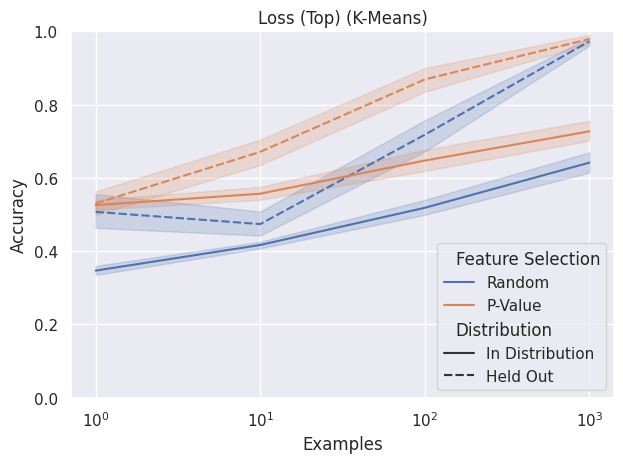

Saving figure to ../outputs/plots/features/CIFAR-10_Loss_Top_feature_select_acc_Logistic.pdf


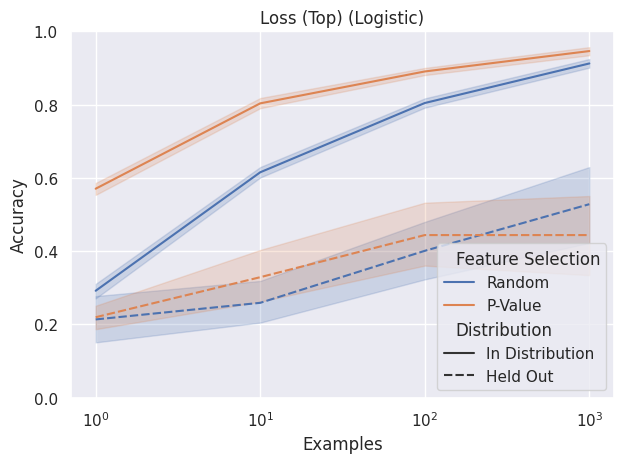

Saving figure to ../outputs/plots/features/CIFAR-10_Prediction_Depth_Bottom_feature_select_acc_K-Means.pdf


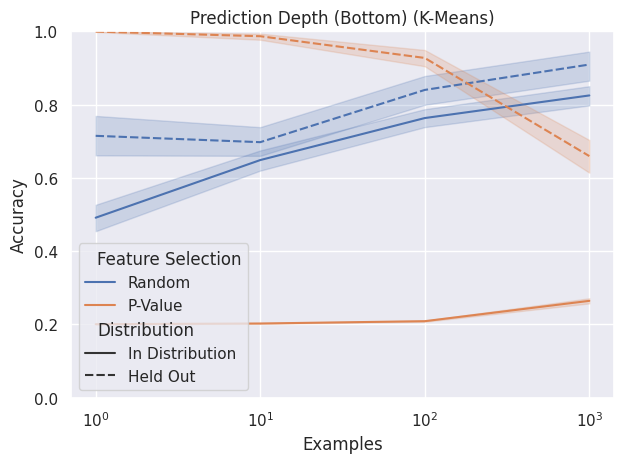

Saving figure to ../outputs/plots/features/CIFAR-10_Prediction_Depth_Bottom_feature_select_acc_Logistic.pdf


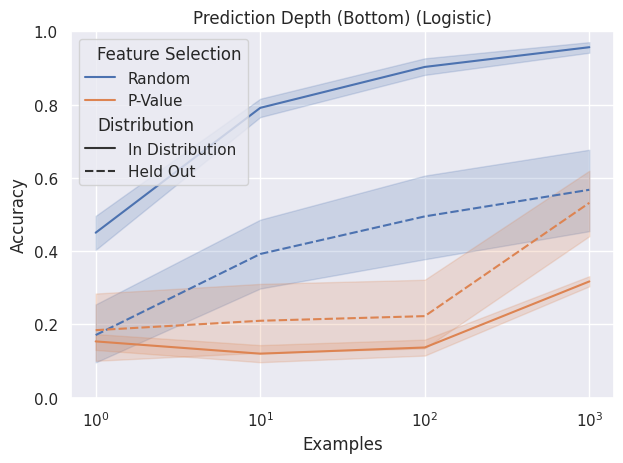

Saving figure to ../outputs/plots/features/CIFAR-10_Prediction_Depth_Top_feature_select_acc_K-Means.pdf


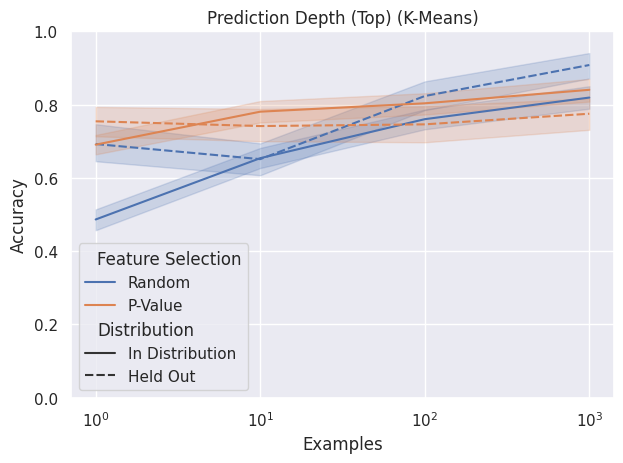

Saving figure to ../outputs/plots/features/CIFAR-10_Prediction_Depth_Top_feature_select_acc_Logistic.pdf


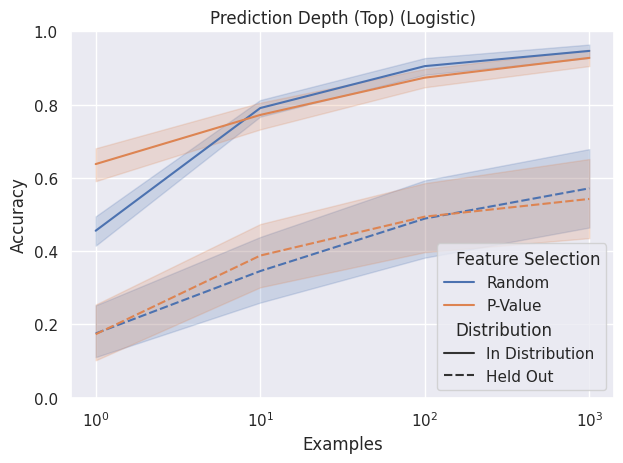

Saving figure to ../outputs/plots/features/CIFAR-10_Self-Supervised_Prototypes_Bottom_feature_select_acc_K-Means.pdf


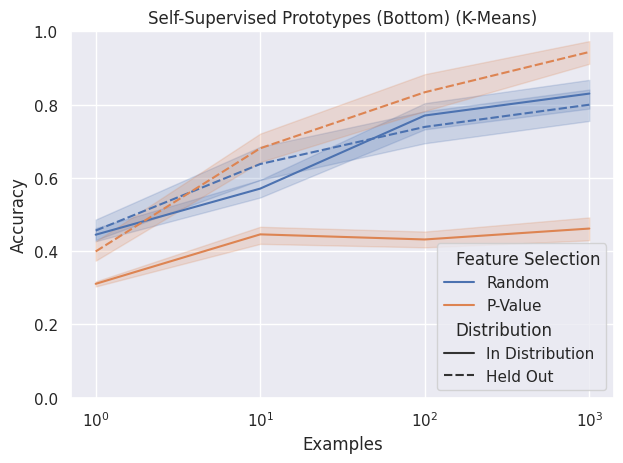

Saving figure to ../outputs/plots/features/CIFAR-10_Self-Supervised_Prototypes_Bottom_feature_select_acc_Logistic.pdf


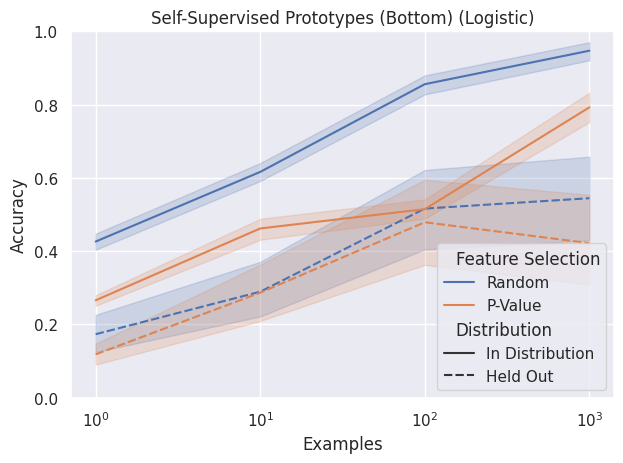

Saving figure to ../outputs/plots/features/CIFAR-10_Self-Supervised_Prototypes_Top_feature_select_acc_K-Means.pdf


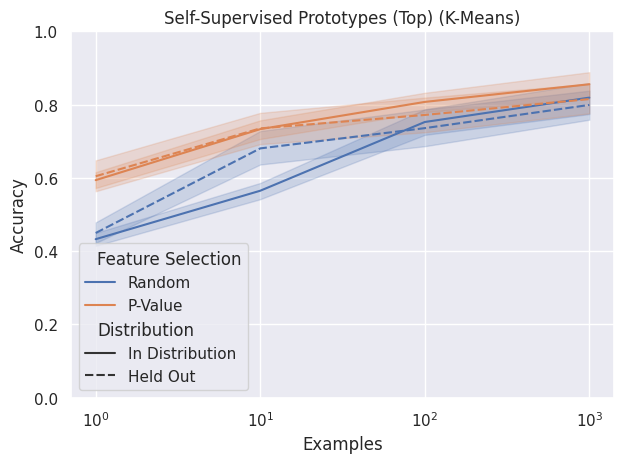

Saving figure to ../outputs/plots/features/CIFAR-10_Self-Supervised_Prototypes_Top_feature_select_acc_Logistic.pdf


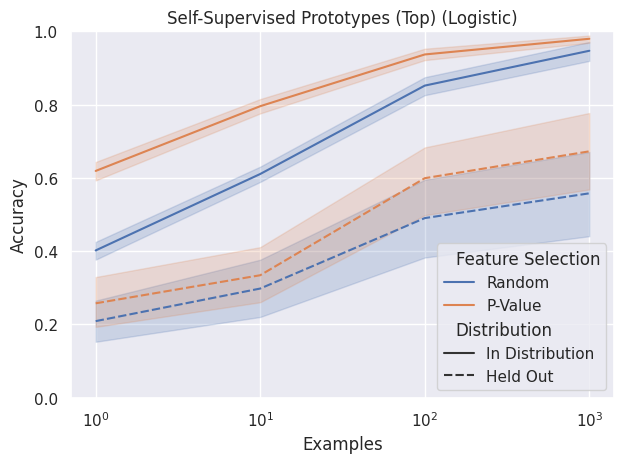

Saving figure to ../outputs/plots/features/CIFAR-10_VoG_Bottom_feature_select_acc_K-Means.pdf


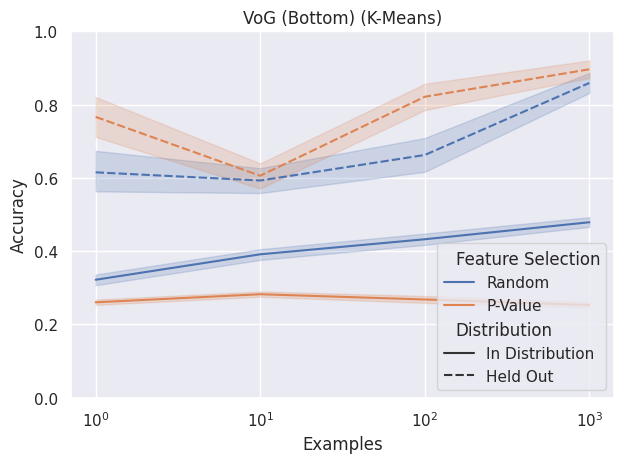

Saving figure to ../outputs/plots/features/CIFAR-10_VoG_Bottom_feature_select_acc_Logistic.pdf


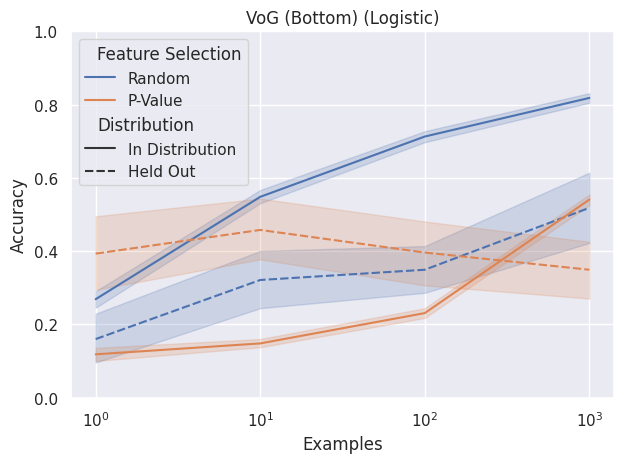

Saving figure to ../outputs/plots/features/CIFAR-10_VoG_Top_feature_select_acc_K-Means.pdf


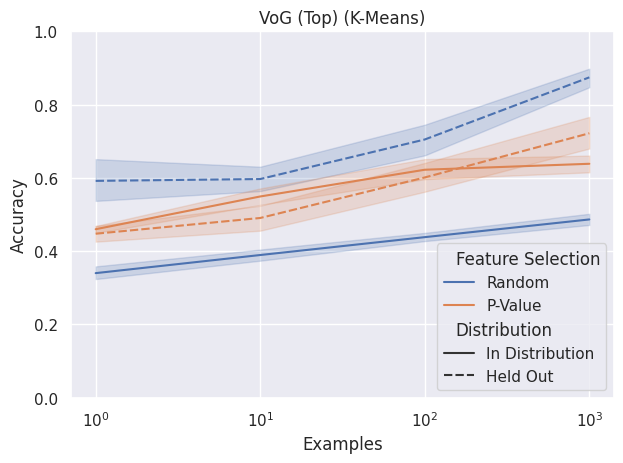

Saving figure to ../outputs/plots/features/CIFAR-10_VoG_Top_feature_select_acc_Logistic.pdf


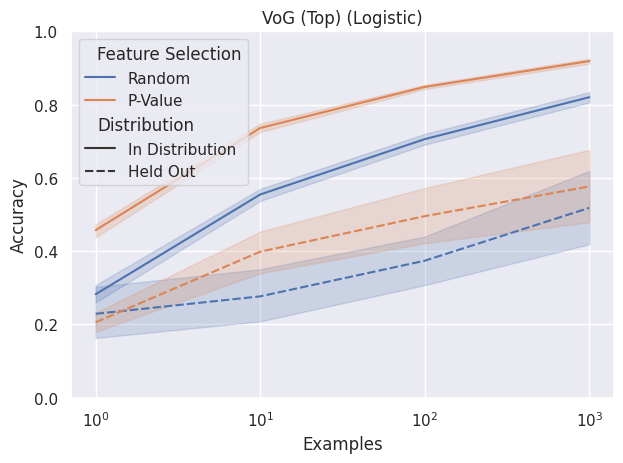

Loaded from files
Saving figure to ../outputs/plots/features/CIFAR-100_Bottom_all_feature_select_acc_K-Means.pdf


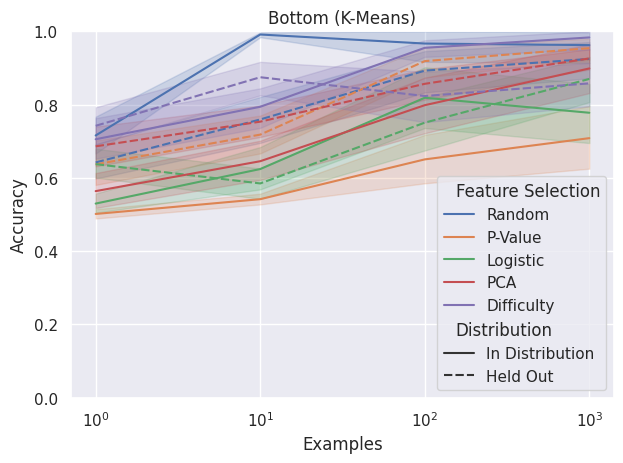

Saving figure to ../outputs/plots/features/CIFAR-100_Bottom_all_feature_select_acc_Logistic.pdf


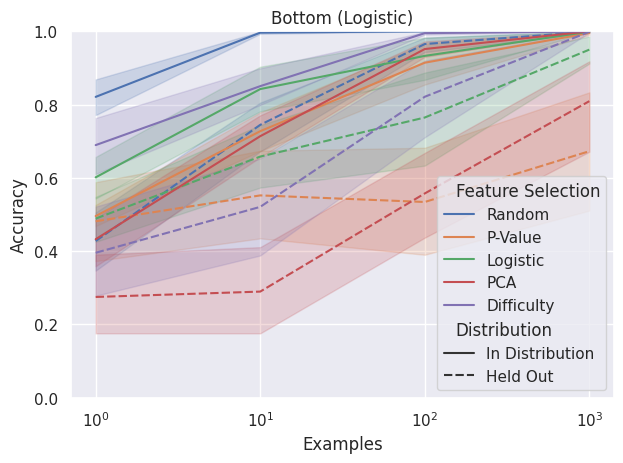

Saving figure to ../outputs/plots/features/CIFAR-100_Bottom_feature_select_acc_K-Means.pdf


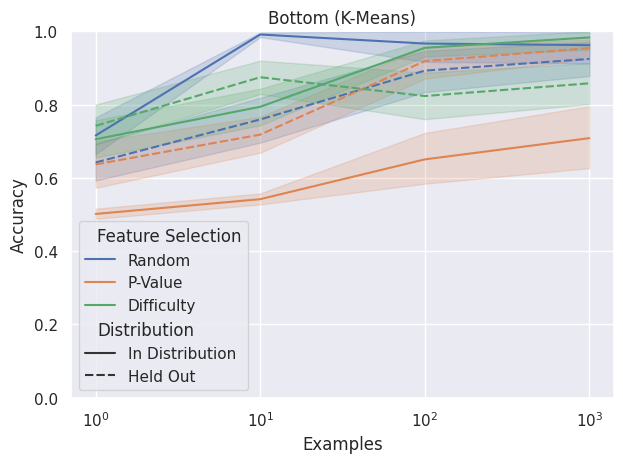

Saving figure to ../outputs/plots/features/CIFAR-100_Bottom_feature_select_acc_Logistic.pdf


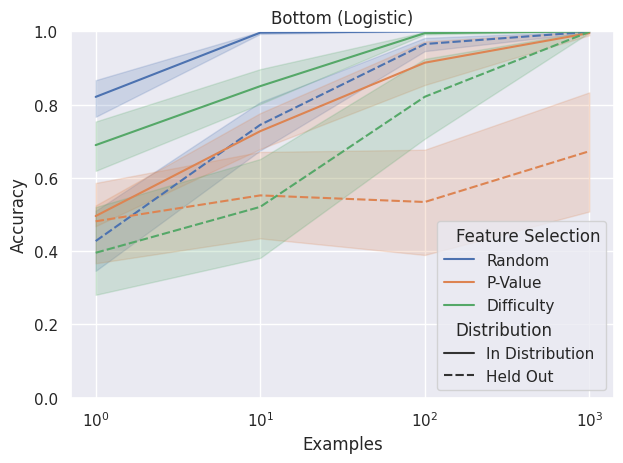

Saving figure to ../outputs/plots/features/CIFAR-100_Top_all_feature_select_acc_K-Means.pdf


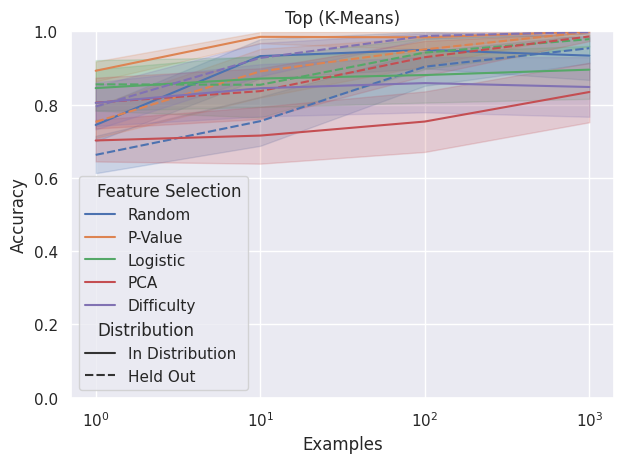

Saving figure to ../outputs/plots/features/CIFAR-100_Top_all_feature_select_acc_Logistic.pdf


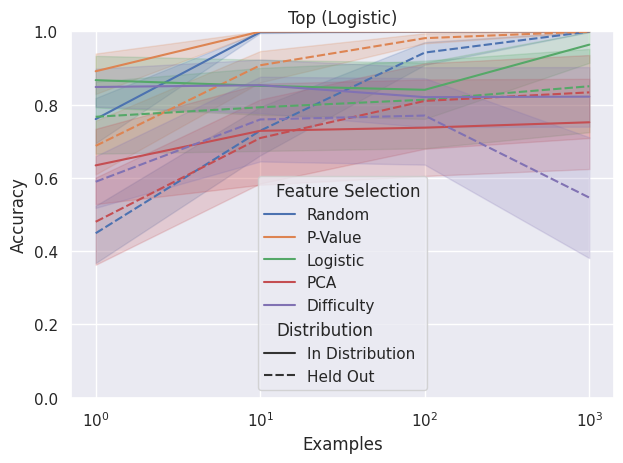

Saving figure to ../outputs/plots/features/CIFAR-100_Top_feature_select_acc_K-Means.pdf


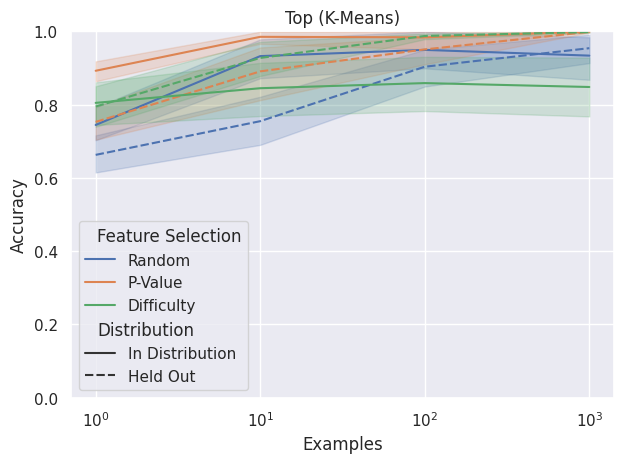

Saving figure to ../outputs/plots/features/CIFAR-100_Top_feature_select_acc_Logistic.pdf


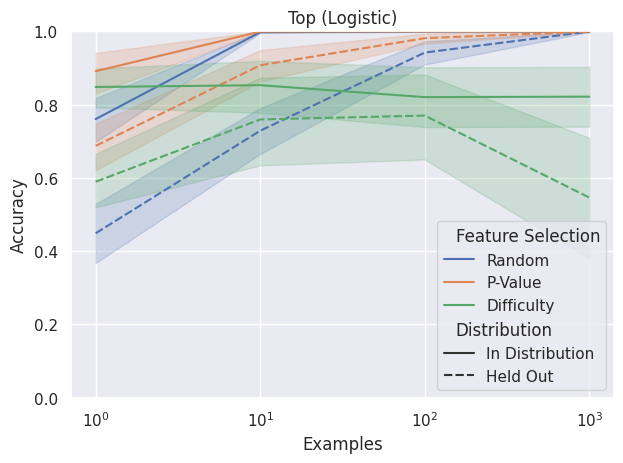

Saving figure to ../outputs/plots/features/CIFAR-100_feature_selector_corr.pdf


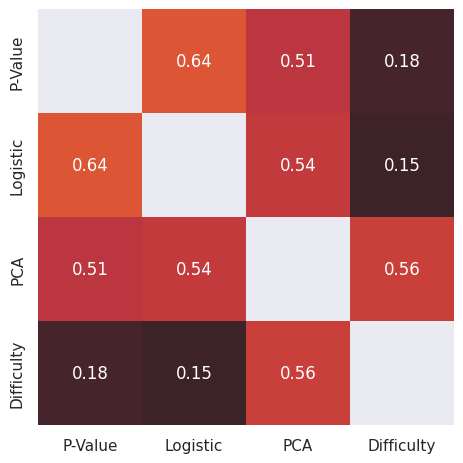

Loaded from files
Loaded from files
Loaded from files
Loaded from files
Loaded from files
Loaded from files
Loaded from files
Saving figure to ../outputs/plots/features/CIFAR-100_Area_Under_Margin_Bottom_feature_select_acc_K-Means.pdf


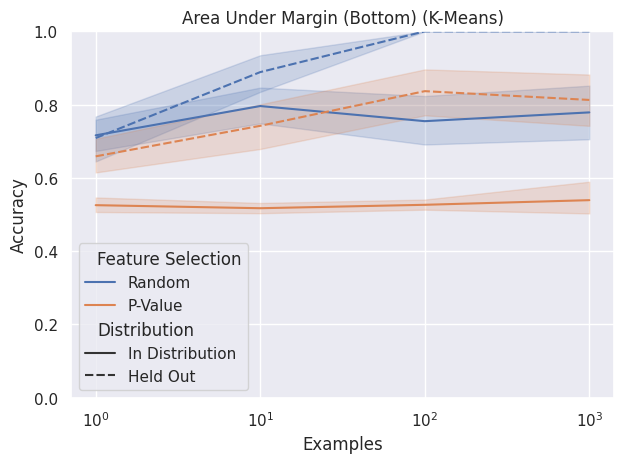

Saving figure to ../outputs/plots/features/CIFAR-100_Area_Under_Margin_Bottom_feature_select_acc_Logistic.pdf


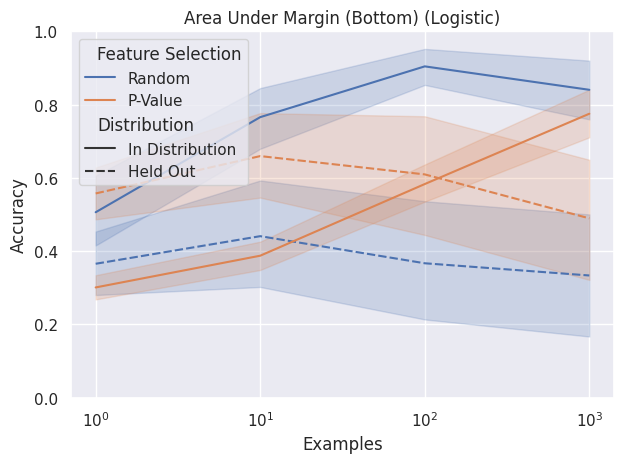

Saving figure to ../outputs/plots/features/CIFAR-100_Area_Under_Margin_Top_feature_select_acc_K-Means.pdf


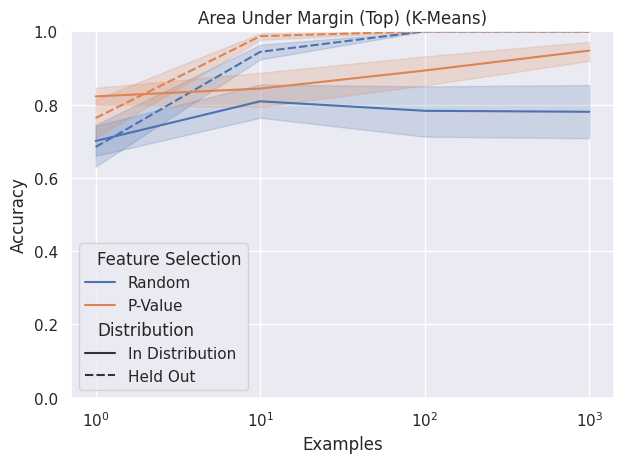

Saving figure to ../outputs/plots/features/CIFAR-100_Area_Under_Margin_Top_feature_select_acc_Logistic.pdf


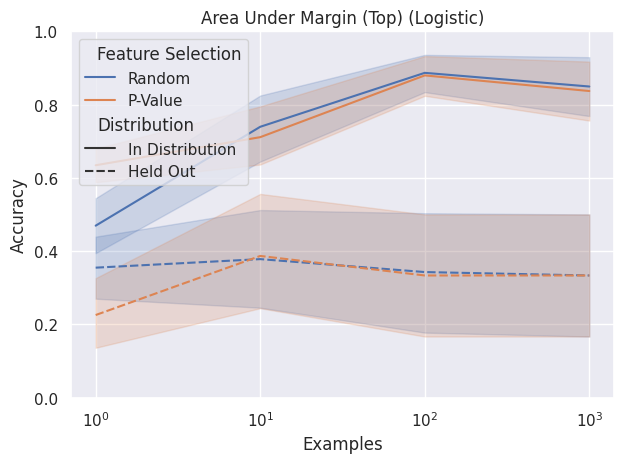

Saving figure to ../outputs/plots/features/CIFAR-100_EL2N_Bottom_feature_select_acc_K-Means.pdf


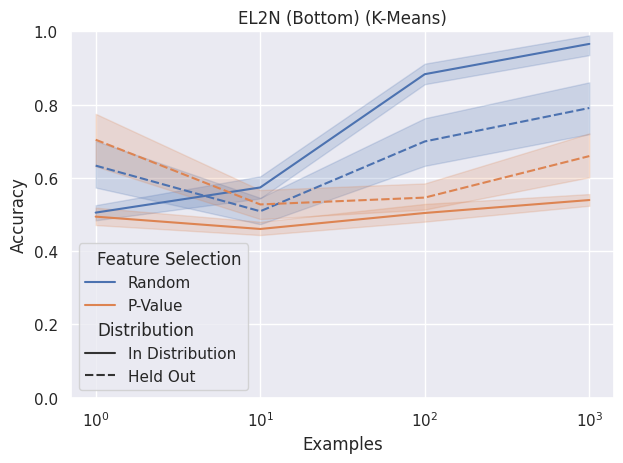

Saving figure to ../outputs/plots/features/CIFAR-100_EL2N_Bottom_feature_select_acc_Logistic.pdf


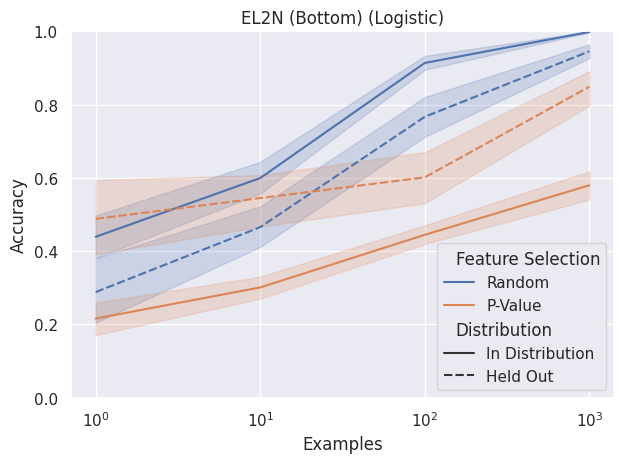

Saving figure to ../outputs/plots/features/CIFAR-100_EL2N_Top_feature_select_acc_K-Means.pdf


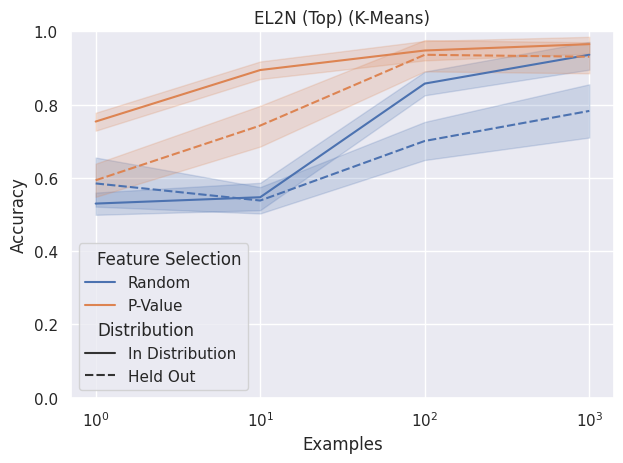

Saving figure to ../outputs/plots/features/CIFAR-100_EL2N_Top_feature_select_acc_Logistic.pdf


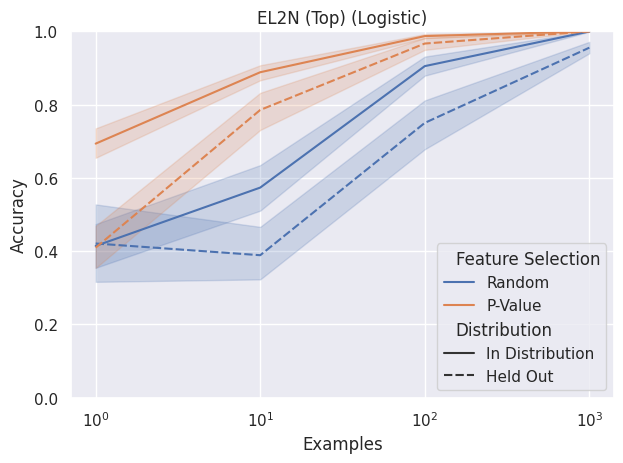

Saving figure to ../outputs/plots/features/CIFAR-100_Forgetting_Bottom_feature_select_acc_K-Means.pdf


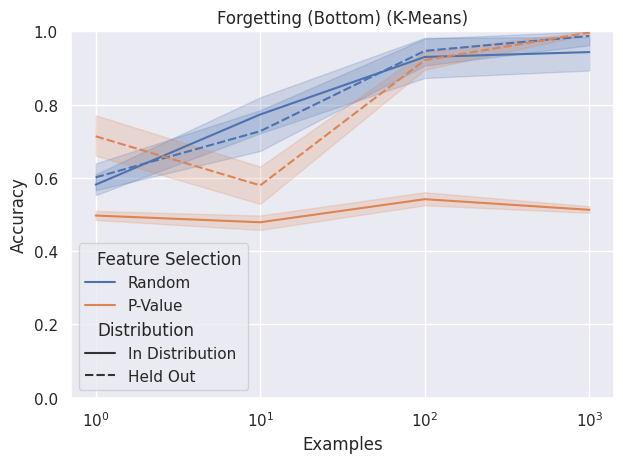

Saving figure to ../outputs/plots/features/CIFAR-100_Forgetting_Bottom_feature_select_acc_Logistic.pdf


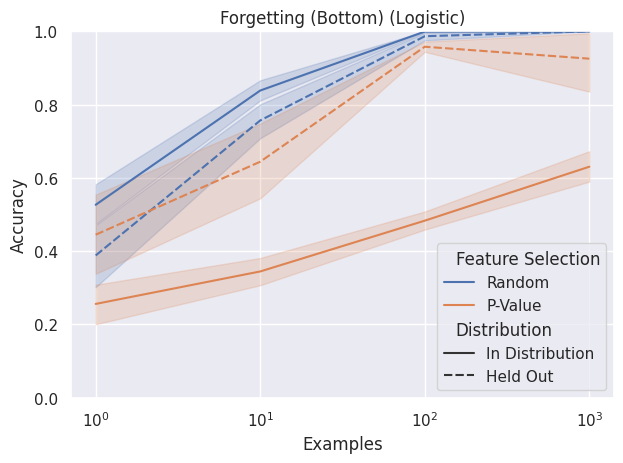

Saving figure to ../outputs/plots/features/CIFAR-100_Forgetting_Top_feature_select_acc_K-Means.pdf


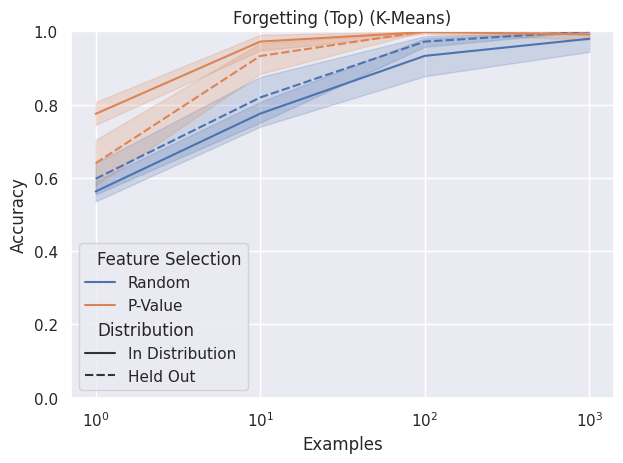

Saving figure to ../outputs/plots/features/CIFAR-100_Forgetting_Top_feature_select_acc_Logistic.pdf


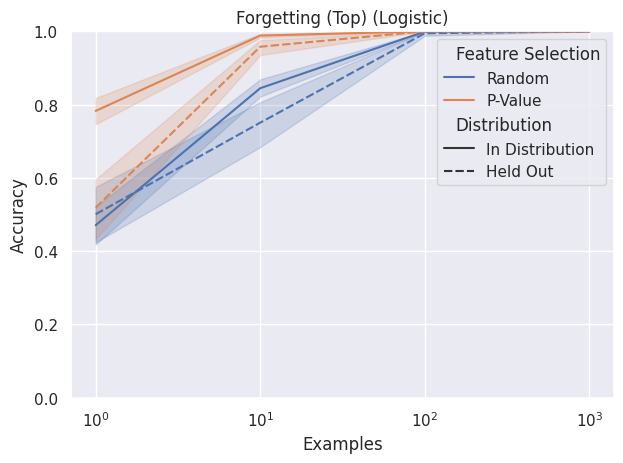

Saving figure to ../outputs/plots/features/CIFAR-100_Loss_Bottom_feature_select_acc_K-Means.pdf


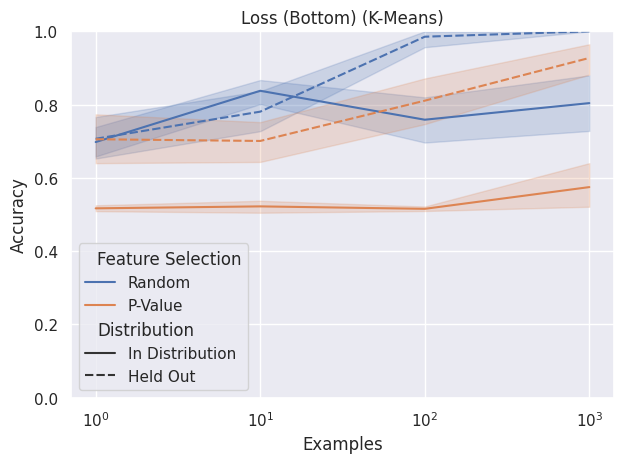

Saving figure to ../outputs/plots/features/CIFAR-100_Loss_Bottom_feature_select_acc_Logistic.pdf


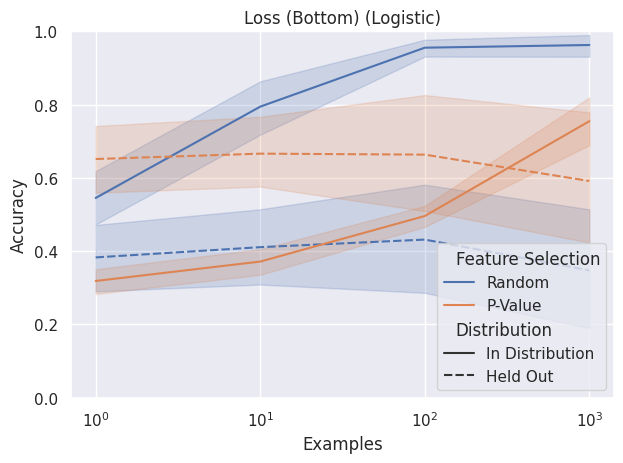

Saving figure to ../outputs/plots/features/CIFAR-100_Loss_Top_feature_select_acc_K-Means.pdf


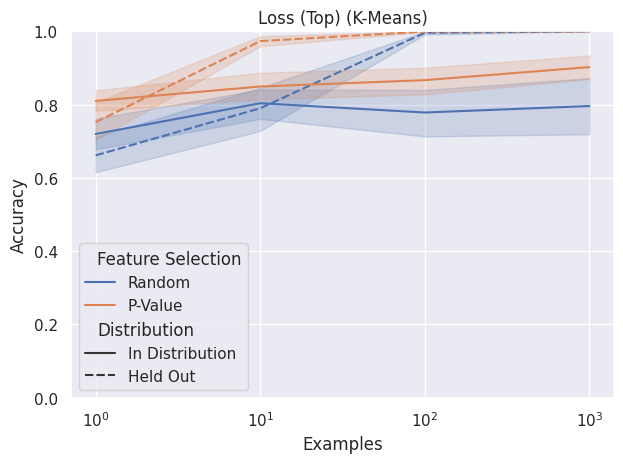

Saving figure to ../outputs/plots/features/CIFAR-100_Loss_Top_feature_select_acc_Logistic.pdf


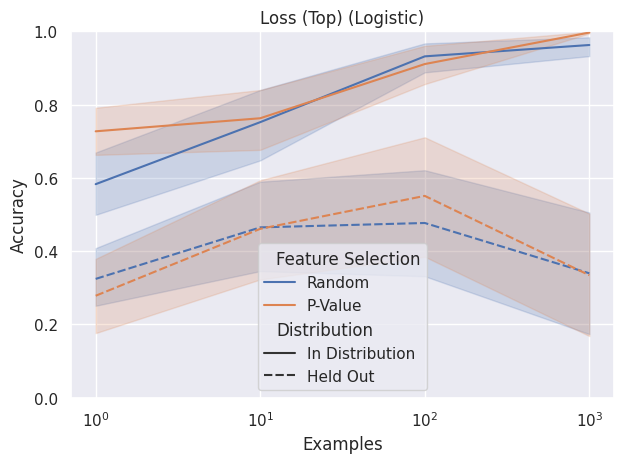

Saving figure to ../outputs/plots/features/CIFAR-100_Prediction_Depth_Bottom_feature_select_acc_K-Means.pdf


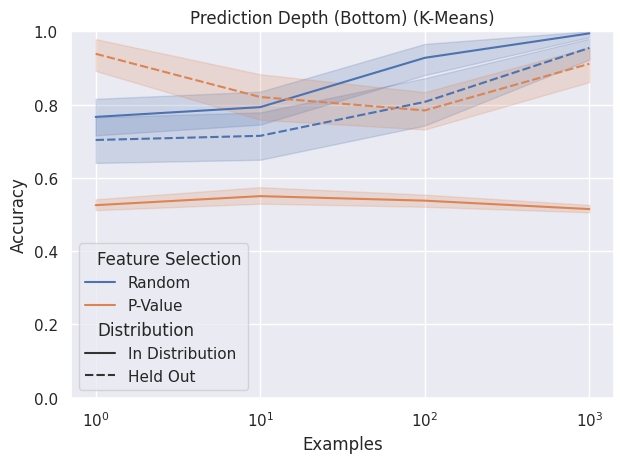

Saving figure to ../outputs/plots/features/CIFAR-100_Prediction_Depth_Bottom_feature_select_acc_Logistic.pdf


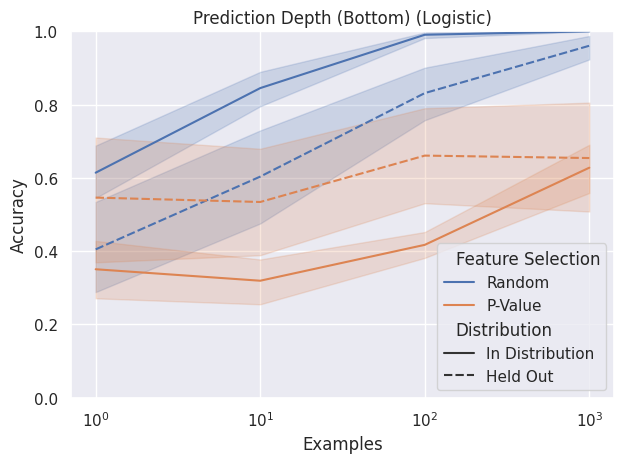

Saving figure to ../outputs/plots/features/CIFAR-100_Prediction_Depth_Top_feature_select_acc_K-Means.pdf


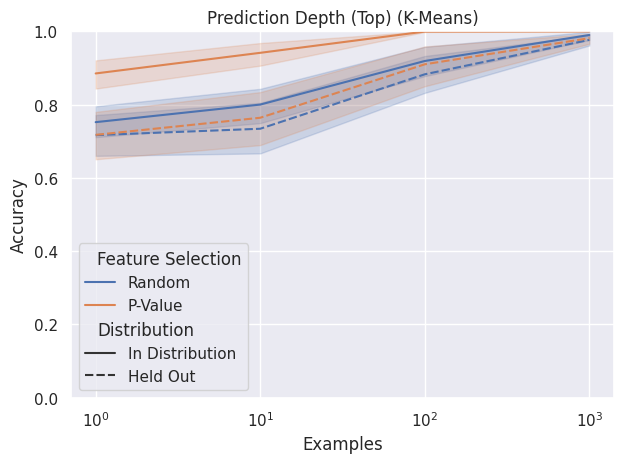

Saving figure to ../outputs/plots/features/CIFAR-100_Prediction_Depth_Top_feature_select_acc_Logistic.pdf


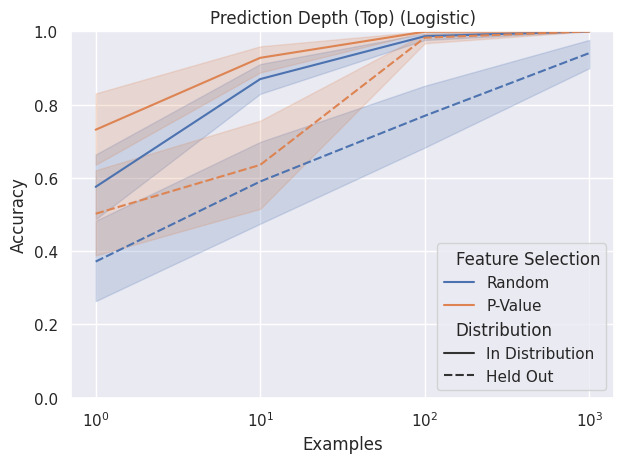

Saving figure to ../outputs/plots/features/CIFAR-100_Self-Supervised_Prototypes_Bottom_feature_select_acc_K-Means.pdf


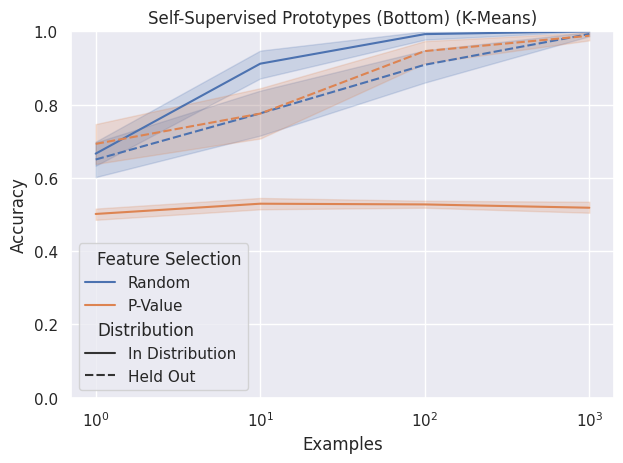

Saving figure to ../outputs/plots/features/CIFAR-100_Self-Supervised_Prototypes_Bottom_feature_select_acc_Logistic.pdf


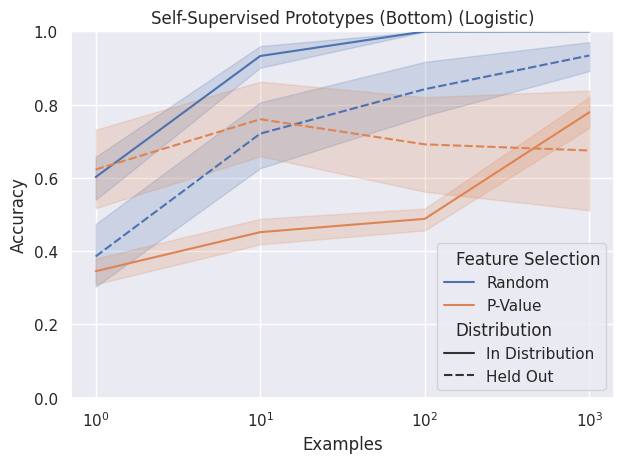

Saving figure to ../outputs/plots/features/CIFAR-100_Self-Supervised_Prototypes_Top_feature_select_acc_K-Means.pdf


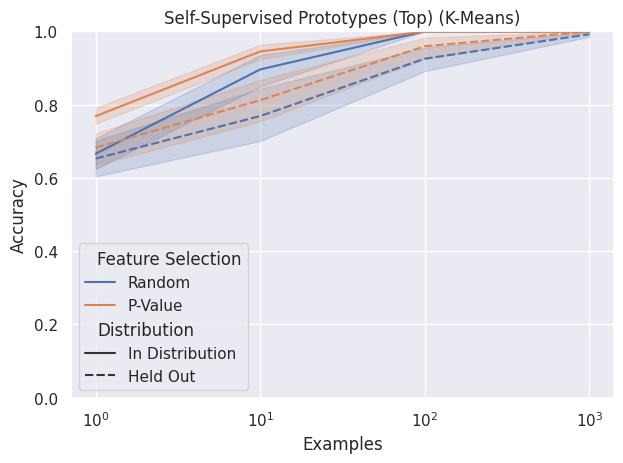

Saving figure to ../outputs/plots/features/CIFAR-100_Self-Supervised_Prototypes_Top_feature_select_acc_Logistic.pdf


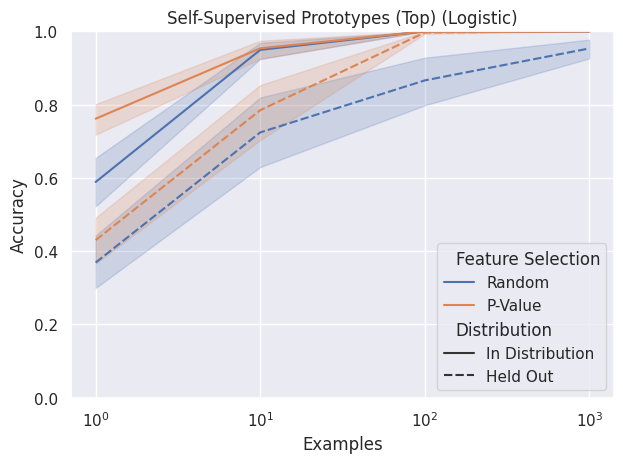

Saving figure to ../outputs/plots/features/CIFAR-100_VoG_Bottom_feature_select_acc_K-Means.pdf


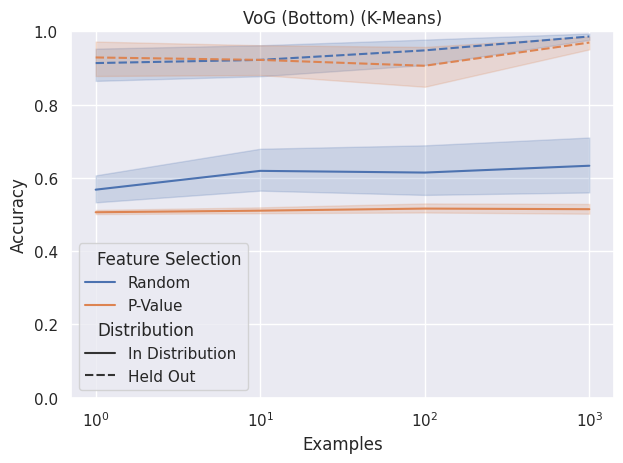

Saving figure to ../outputs/plots/features/CIFAR-100_VoG_Bottom_feature_select_acc_Logistic.pdf


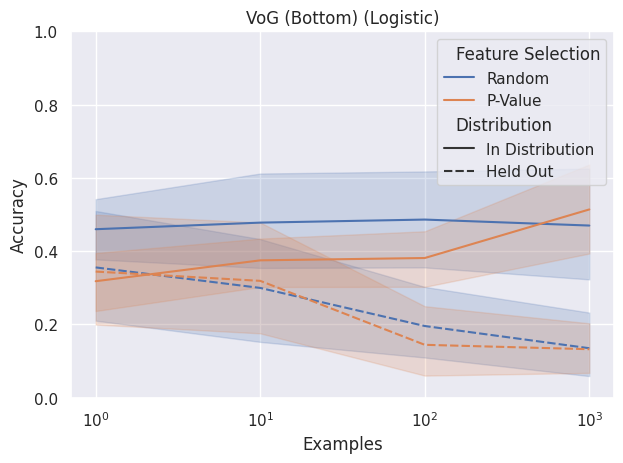

Saving figure to ../outputs/plots/features/CIFAR-100_VoG_Top_feature_select_acc_K-Means.pdf


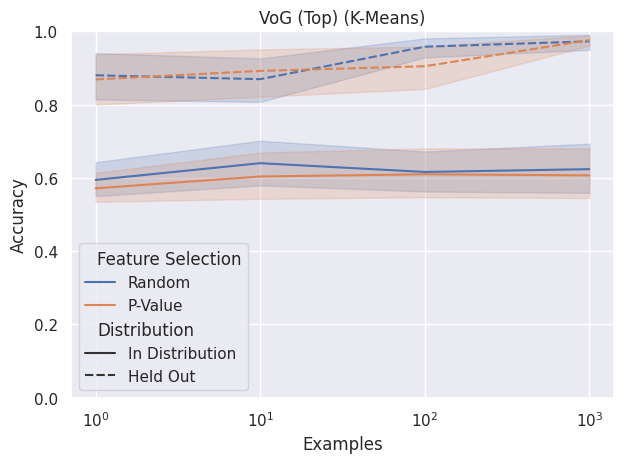

Saving figure to ../outputs/plots/features/CIFAR-100_VoG_Top_feature_select_acc_Logistic.pdf


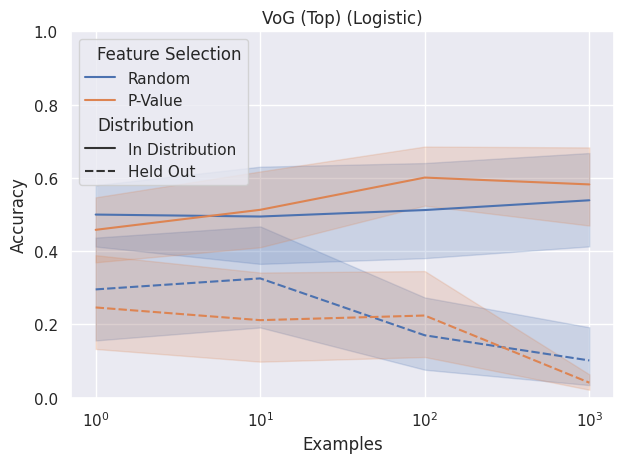

<Figure size 640x480 with 0 Axes>

In [11]:
for dataset, df in dfs.groupby("Dataset"):
    # all scores
    result_df, select_df = feature_select_experiment(df, FEATURE_SELECTORS, EXAMPLE_SUBSETS, CLASSIFIERS, f"feature_select_{dataset}")
    plot_all_score_results(result_df, select_df, dataset)

    # one score at a time
    per_score_results, per_score_selected = [], []
    for score_name, df in df.groupby("Short Name"):
        result_df, select_df = feature_select_experiment(df, PER_SCORE_SELECTORS, EXAMPLE_SUBSETS, CLASSIFIERS, f"feature_select_{dataset}_{score_name}")
        result_df["Score"] = score_name
        select_df["Score"] = score_name
        per_score_results.append(result_df)
        per_score_selected.append(select_df)

    per_score_results = pd.concat(per_score_results)
    per_score_selected = pd.concat(per_score_selected)

    for (score, ord), sub_df in per_score_results[per_score_results["Examples"].isin(EXAMPLE_SUBSETS)].groupby(["Score", "Selection Order"]):
        plot_feature_select_acc(sub_df, [x[0] for x in PER_SCORE_SELECTORS], CLASSIFIERS, f"{score} ({ord})", name=f"{dataset} {score} {ord}")